In [1]:
import numpy as np
import matplotlib.pyplot as plt
f0 = 7e-2
delta = 20e-3
R = 1.e-3

In [2]:
r = np.linspace(-R, R, 400)
s_sm = r**2/(4*f0) - r**4*delta/(8*f0**2*R**2) + r**6*delta*(R**2+8*f0*delta)/(96*f0**4*R**4)
s_am = R**2/(4*delta) * np.log(1+delta/f0*(r/R)**2)
r2 = r**2
sag = (
            (1.0 / (4 * f0)) * r2
            - (delta / (8 * f0**2 * R**2)) * r2**2
            + delta
            * (R**2 + 8 * f0 * delta)
            / (96 * f0**4 * R**4)
            * r2**3
        )
s_pa = r**2/(4*f0)

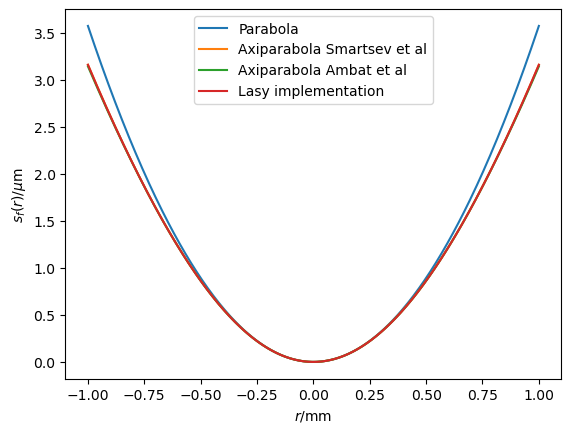

In [3]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(r*1e3, s_pa*1e6, label="Parabola")
ax.plot(r*1e3, s_sm*1e6, label="Axiparabola Smartsev et al")
ax.plot(r*1e3, s_am*1e6, label="Axiparabola Ambat et al")
ax.plot(r*1e3, sag*1e6, label="Lasy implementation")
ax.legend()
ax.set_xlabel("$r$/mm")
ax.set_ylabel("$s_f(r)/\\mu$m")

plt.show()

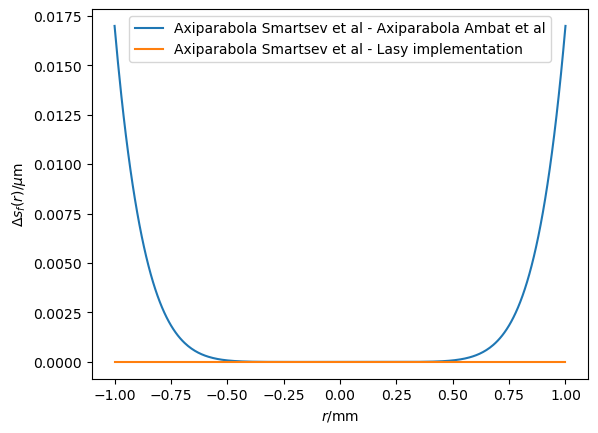

In [4]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(r*1e3, s_sm*1e6-s_am*1e6, label="Axiparabola Smartsev et al - Axiparabola Ambat et al")
ax.plot(r*1e3, s_sm*1e6-sag*1e6, label="Axiparabola Smartsev et al - Lasy implementation")
#ax.plot(r*1e3, s_pa*1e6 - s_am*1e6, label="Axiparabola Smartsev et al")
ax.legend()
ax.set_xlabel("$r$/mm")
ax.set_ylabel("$\Delta s_f(r)/\\mu$m")

plt.show()

In [5]:
r = np.linspace(0, R, 4000)
import axiparabola_theory as axi

fr = axi.f(r, axi.Axiparabola_Ambat(f0, delta, R))
sfr = axi.sf(r, axi.Axiparabola_Ambat(f0, delta, R))

left = (sfr-fr) + np.sqrt((fr-sfr)**2 + r**2)
right = R**2/(4*delta) * ((2*delta*r)/(f0*R**2*(delta/(f0*R**2)*r**2+1))) * r

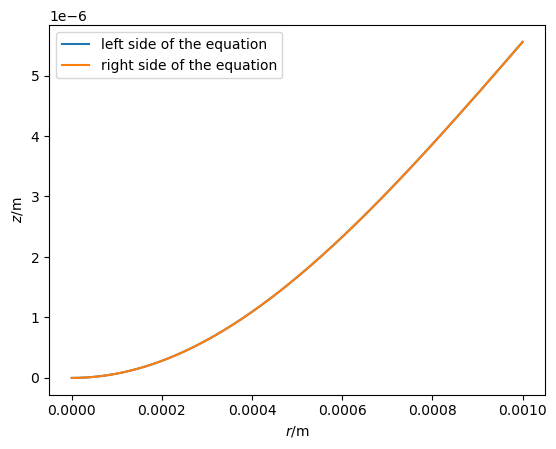

In [6]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(r, left, label="left side of the equation")
ax.plot(r, right, label="right side of the equation")
ax.set_xlabel("$r$/m")
ax.set_ylabel("$z$/m")
ax.legend()

plt.show()

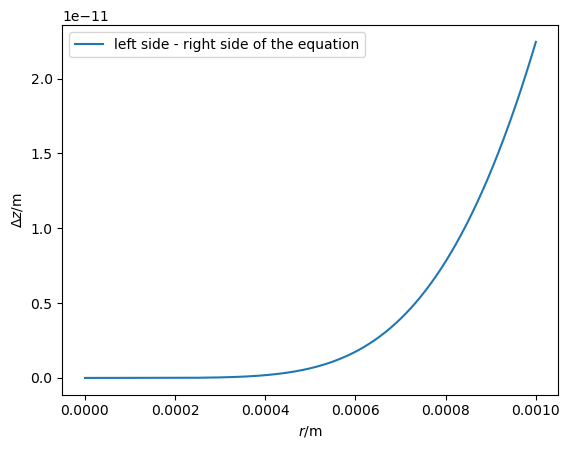

In [7]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(r, left-right, label="left side - right side of the equation")
ax.set_xlabel("$r$/m")
ax.set_ylabel("$\Delta z$/m")
ax.legend()

plt.show()